
$q_{ij} = \frac{|x_i - x_j|}{h}$


$
W_{ij} = W(q_{ij}, h)
= \frac{1}{h}
\begin{cases}
\frac{2}{3} - q_{ij}^2 + \frac{1}{2} q_{ij}^3,
& 0 \le q_{ij} < 1, \\[6pt]
\frac{1}{6}(2 - q_{ij})^3,
& 1 \le q_{ij} < 2, \\[6pt]
0,
& q_{ij} \ge 2 .
\end{cases}
$


$$
\nabla_i W_{ij} = \frac{\partial W_{ij}}{\partial x_i}
$$

$$
\nabla_i W_{ij}
=
\frac{dW}{dr}\,\frac{x_i-x_j}{|x_i-x_j|}
\qquad \text{with} \qquad
r = |x_i-x_j|
$$

$$
\frac{dW}{dr}
=
\frac{1}{h^2}
\begin{cases}
-2q_{ij} + \frac{3}{2}q_{ij}^2, & 0 \le q_{ij} < 1,\\[4pt]
-\frac{1}{2}(2-q_{ij})^2, & 1 \le q_{ij} < 2,\\[4pt]
0, & q_{ij} \ge 2.
\end{cases}
$$


In [1]:
#Functions

def W_cubic_1d(r, h): #Karnel function
    q = np.abs(r) / h
    sigma = 2.0 / 3.0  # 1D normalization for M4 cubic spline
    out = np.zeros_like(q)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)

    out[m1] = 1 - 1.5*q[m1]**2 + 0.75*q[m1]**3
    out[m2] = 0.25*(2 - q[m2])**3

    return (sigma / h) * out

def dWdx_cubic_1d(r, h): #Derivative of the karnel function
    q = np.abs(r) / h
    s = np.sign(r)
    sigma = 2.0 / 3.0
    df = np.zeros_like(q)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)

    df[m1] = -3*q[m1] + 2.25*q[m1]**2
    df[m2] = -0.75*(2 - q[m2])**2

    return (sigma / h) * df * (s / h)

def compute_density(x, m, h): #Density/rho
    dx = x[:, None] - x[None, :]
    Wij = W_cubic_1d(dx, h)
    return (m[None, :] * Wij).sum(axis=1)

def compute_pressure(rho, e, gamma=1.4): #Presure/P
    return (gamma - 1.0) * rho * e

def compute_soundspeed(e, gamma=1.4): #Sound speed/c
    return np.sqrt((gamma - 1.0) * e)

def compute_accel_and_dedt(x, v, rho, p, e, m, h, use_viscosity=True): #Computation of accelaratation (dv/dt) and sound speed derivative (de/dt)
    N = x.size
    dx = x[:, None] - x[None, :]          # x_ij
    dv = v[:, None] - v[None, :]          # v_ij
    gradW = dWdx_cubic_1d(dx, h)          # ∇_i W_ij in 1D

    # Symmetric pressure term: (p_i/rho_i^2 + p_j/rho_j^2)
    A = (p / (rho**2))[:, None] + (p / (rho**2))[None, :]

    # Artificial viscosity Π_ij (Eqs 3-7)
    Pi = np.zeros((N, N), dtype=float)
    if use_viscosity:
        c = compute_soundspeed(e, gamma)
        cbar = 0.5 * (c[:, None] + c[None, :])          # Eq (6)
        rhobar = 0.5 * (rho[:, None] + rho[None, :])    # Eq (5)
        hij = h                                         # constant h => h_ij = h (Eq 7)
        phi = 0.1 * hij                                 # to avoid divergence

        # condition v_ij * x_ij < 0 (1D dot product)
        cond = (dv * dx) < 0

        # Eq (4): φ_ij = h_ij (v_ij x_ij) / (|x_ij|^2 + φ^2)
        denom = (dx*dx + phi*phi)
        # avoid 0/0 on diagonal (doesn't matter if we zero diagonal anyway)
        denom = np.where(denom == 0, 1.0, denom)
        phij = hij * (dv * dx) / denom

        # Eq (3)
        Pi_val = (-alphaPi * cbar * phij + betaPi * phij**2) / rhobar
        Pi = np.where(cond, Pi_val, 0.0)

    # No self-interaction
    np.fill_diagonal(A, 0.0)
    np.fill_diagonal(Pi, 0.0)

    # Eq (2): dv_i/dt = - sum_j m_j (A_ij + Pi_ij) ∇_i W_ij
    coeff = (A + Pi)
    accel = - (m[None, :] * coeff * gradW).sum(axis=1)

    # Eq (2): de_i/dt = 1/2 sum_j m_j (A_ij + Pi_ij) (v_i - v_j) · ∇_i W_ij
    dedt = 0.5 * (m[None, :] * coeff * dv * gradW).sum(axis=1)

    return accel, dedt


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Project 1: 1-D Sod’s shock tube

# particle positions
dxL, NL = 0.001875, 320
dxR, NR = 0.0075, 80
xL = -0.6 + dxL/2 + np.arange(NL)*dxL
xR =  0.0 + dxR/2 + np.arange(NR)*dxR
x = np.concatenate([xL, xR])
N = x.size

left  = x <= 0
right = x > 0

rho = np.zeros(N)
v   = np.zeros(N)
e   = np.zeros(N)
p   = np.zeros(N)
m   = np.zeros(N)

v   = np.zeros(N)

# Left side
rho[left] = 1.0
v[left]   = 0.0
e[left]   = 2.5
p[left]   = 1.0

# Right side
rho[right] = 0.25
v[right]   = 0.0
e[right]   = 1.795
p[right]   = 0.1795

# constants
gamma=1.4
eta=1.5 #between 1.2 and 1.5
alphaPi=1
betaPi=1

# Mass (constant for all particles)
m[:] = 0.001875

#Constants
h_0=eta*(m/rho)
h=0.5*(h_0[-1]+h_0[0])
#h=0.009
gamma=1.4

# ------ Parameters to change --------
nsteps=300
dt=0.0005

from matplotlib.animation import FuncAnimation, FFMpegWriter

fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axs = axs.ravel()

for ax in axs:
    ax.set_xlim(-0.4, 0.4)

axs[0].set_ylim(0, 1.2)
axs[1].set_ylim(0, 1.2)
axs[2].set_ylim(1.8, 2.6)
axs[3].set_ylim(0, 0.8)

# Create empty line objects (important!)
line_rho, = axs[0].plot([], [], lw=1)
axs[0].set_ylabel(r"$\rho(x)$")

line_p, = axs[1].plot([], [], lw=1)
axs[1].set_ylabel(r"$p(x)$")

line_e, = axs[2].plot([], [], lw=1)
axs[2].set_xlabel(r"$x$")
axs[2].set_ylabel(r"$e(x)$")

line_v, = axs[3].plot([], [], lw=1)
axs[3].set_xlabel(r"$x$")
axs[3].set_ylabel(r"$v(x)$")

title = fig.suptitle("")

def update(n):
    global x, v, e

    # --- SPH step ---
    rho = compute_density(x, m, h)
    p   = compute_pressure(rho, e, gamma)

    a, dedt = compute_accel_and_dedt(
        x, v, rho, p, e, m, h,
        use_viscosity=True
    )

    v += dt * a
    e += dt * dedt
    x += dt * v

    # --- Sort for clean plotting ---
    order = np.argsort(x)
    xs = x[order]
    rhos = rho[order]
    ps = p[order]
    es = e[order]
    vs = v[order]

    # --- Update lines only ---
    line_rho.set_data(xs, rhos)
    line_p.set_data(xs, ps)
    line_e.set_data(xs, es)
    line_v.set_data(xs, vs)

    title.set_text(
        f"Sod shock tube (SPH), dt={dt}, step={n}, h={h:.3g}"
    )

    return line_rho, line_p, line_e, line_v, title

anim = FuncAnimation(fig, update, frames=nsteps, interval=30, blit=False)

writer = FFMpegWriter(fps=20)
anim.save("sod_shock.mp4", writer=writer, dpi=150)

plt.close(fig)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load the files ------------

G = 6.67430e-11  # SI

def load_planet_dat(file, gamma=1.4, dtype=np.float64):
    """
    Load a PlanetXXXX.dat file with columns:
    x y z vx vy vz m rho p  (SI units)
    Returns:
      x:   (N,3)
      v:   (N,3)
      m:   (N,)
      rho: (N,)
      p:   (N,)
      e:   (N,)   internal energy per unit mass
    """
    data = np.loadtxt("/home/ricardofernandes/Área_de_Trabalho/FYSN33/Project1/" + file, dtype=dtype) #Change depending of the specific location

    if data.ndim != 2 or data.shape[1] < 9: #Wrong number of colloumns
        raise ValueError(f"Expected at least 9 columns, got shape {data.shape}") 

    x = data[:, 0:3]
    v = data[:, 3:6]
    m = data[:, 6]
    rho = data[:, 7]
    p = data[:, 8]

    # Safety: avoid division by zero / negative densities
    if np.any(rho <= 0):
        bad = np.where(rho <= 0)[0][:10]
        raise ValueError(f"Non-positive rho at rows {bad} (showing up to 10).")

    # Invert EOS: p = (gamma-1) rho e  => e = p / ((gamma-1) rho)
    e = p / ((gamma - 1.0) * rho)

    return x, v, m, rho, p, e


def summarize_state(x, v, m, rho, p, e, name="state"):
    """Quick prints to sanity-check the loaded file."""
    N = x.shape[0]
    total_mass = m.sum()
    com = (m[:, None] * x).sum(axis=0) / total_mass
    vcom = (m[:, None] * v).sum(axis=0) / total_mass

    print(f"{name}: N={N}")
    print(f"  mass total = {total_mass:.6e} kg")
    print(f"  COM pos    = {com}")
    print(f"  COM vel    = {vcom}")
    print(f"  rho[min,max] = {rho.min():.6e}, {rho.max():.6e}")
    print(f"  p  [min,max] = {p.min():.6e}, {p.max():.6e}")
    print(f"  e  [min,max] = {e.min():.6e}, {e.max():.6e}")


def dphi_dr(r, h):
    """
    Implements Eq. (11): dφ(r,h)/dr as a function of R=r/h.
    r: (N,N) distances
    h: scalar (constant smoothing length)
    returns: (N,N)
    """
    R = r / h
    out = np.zeros_like(r)

    m1 = (R >= 0) & (R < 1)
    m2 = (R >= 1) & (R < 2)
    m3 = (R >= 2)

    # Eq (11), piecewise
    out[m1] = (1 / h**2) * ( (4/3)*R[m1] - (6/5)*R[m1]**3 + 0.5*R[m1]**4 )
    out[m2] = (1 / h**2) * ( (8/3)*R[m2] - 3*R[m2]**2 + (6/5)*R[m2]**3 - (1/6)*R[m2]**4 - (1/15)/R[m2]**2 )
    out[m3] = 1 / (r[m3]**2)

    # handle diagonal safely (r=0)
    np.fill_diagonal(out, 0.0)
    return out

def gravity_accel(x, m, h):
    """
    Computes a_grav for each particle using Eq. (12).
    x: (N,3)
    m: (N,)
    h: scalar constant
    returns: (N,3)
    """
    # r_vec[i,j,:] = x_i - x_j
    r_vec = x[:, None, :] - x[None, :, :]     # (N,N,3)
    r = np.linalg.norm(r_vec, axis=2)         # (N,N)

    # unit vectors; avoid divide-by-zero
    inv_r = np.zeros_like(r)
    mask = r > 0
    inv_r[mask] = 1.0 / r[mask]

    # (N,N)
    r_hat = r_vec * inv_r[:, :, None]         # (N,N,3)

    # symmetric softening per Eq (12): average of grad φ with h_i and h_j.
    # With constant h, this just becomes the same h twice -> same result.
    dph = dphi_dr(r, h)                       # (N,N)

    # ∇φ = (dφ/dr) r_hat
    grad_phi = dph[:, :, None] * r_hat        # (N,N,3)

    # Eq (12) has a factor -(G/2) sum_j m_j (∇φ(h_i)+∇φ(h_j))
    # For constant h: (∇φ+∇φ)/2 = ∇φ, so effectively: a_i = -G * sum_j m_j ∇φ_ij
    a = -G * (m[None, :, None] * grad_phi).sum(axis=1)  # (N,3)

    return a

def recenter(x, v, m):
    M = m.sum()
    com  = (m[:,None] * x).sum(axis=0) / M
    vcom = (m[:,None] * v).sum(axis=0) / M
    return x - com, v - vcom

def make_two_body_ic(x, v, m, rho, p, e, sep, b, vrel, spin_omega=None):
    """
    sep: initial x separation between planet centers (meters)
    b:   impact parameter offset in y (meters)
    vrel: relative speed along x (m/s), planets approach each other
    spin_omega: None or np.array([wx, wy, wz]) in rad/s
    """
    # Body 1
    x1, v1 = x.copy(), v.copy()
    m1, rho1, p1, e1 = m.copy(), rho.copy(), p.copy(), e.copy()

    # Body 2 (copy)
    x2, v2 = x.copy(), v.copy()
    m2, rho2, p2, e2 = m.copy(), rho.copy(), p.copy(), e.copy()

    # Shift centers
    x1 += np.array([-0.5*sep, -0.5*b, 0.0])
    x2 += np.array([+0.5*sep, +0.5*b, 0.0])

    # Give approach velocities
    v1 += np.array([+0.5*vrel, 0.0, 0.0])
    v2 += np.array([-0.5*vrel, 0.0, 0.0])

    # Optional spin about each body's own COM: v += ω × (r - r_com)
    if spin_omega is not None:
        c1 = (m1[:,None] * x1).sum(axis=0) / m1.sum()
        c2 = (m2[:,None] * x2).sum(axis=0) / m2.sum()
        v1 += np.cross(spin_omega, x1 - c1)
        v2 += np.cross(spin_omega, x2 - c2)

    # Merge
    X = np.vstack([x1, x2])
    V = np.vstack([v1, v2])
    M = np.concatenate([m1, m2])

    RHO = np.concatenate([rho1, rho2])
    P   = np.concatenate([p1, p2])
    E   = np.concatenate([e1, e2])

    # Put whole system into COM frame
    X, V = recenter(X, V, M)

    return X, V, M, RHO, P, E



In [ ]:
#Functions for the 3D case. Some of them are copies from before

def W_cubic_3d(r, h):
    q = r / h
    sigma = 1.0 / np.pi
    W = np.zeros_like(q)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)

    W[m1] = 1 - 1.5*q[m1]**2 + 0.75*q[m1]**3
    W[m2] = 0.25*(2 - q[m2])**3

    return sigma * W / h**3

def gradW_cubic_3d(r_vec, h):
    r = np.linalg.norm(r_vec, axis=2)
    q = r / h
    sigma = 1.0 / np.pi

    dWdr = np.zeros_like(r)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)

    dWdr[m1] = -3*q[m1] + 2.25*q[m1]**2
    dWdr[m2] = -0.75*(2 - q[m2])**2

    dWdr *= sigma / h**4

    # unit vectors r̂
    inv_r = np.zeros_like(r)
    mask = r > 0
    inv_r[mask] = 1.0 / r[mask]

    return dWdr[:, :, None] * r_vec * inv_r[:, :, None]

def compute_density_3d(x, m, h):
    r_vec = x[:, None, :] - x[None, :, :]
    r = np.linalg.norm(r_vec, axis=2)
    Wij = W_cubic_3d(r, h)
    return (m[None, :] * Wij).sum(axis=1)

def compute_pressure(rho, e, gamma=1.4):
    return (gamma - 1.0) * rho * e

def compute_soundspeed(e, gamma=1.4):
    return np.sqrt((gamma - 1.0) * e)

def compute_accel_and_dedt_3d(x, v, rho, p, e, m, h, gamma=1.4,
                              alphaPi=1.0, betaPi=1.0, use_viscosity=True):
    """
    x:   (N,3)
    v:   (N,3)
    rho: (N,)
    p:   (N,)
    e:   (N,)
    m:   (N,)
    h:   scalar (constant smoothing length)
    returns:
      accel: (N,3)
      dedt:  (N,)
    """
    N = x.shape[0]  # IMPORTANT (not x.size)

    # Pairwise vectors: r_ij = x_i - x_j, v_ij = v_i - v_j
    r_vec = x[:, None, :] - x[None, :, :]   # (N,N,3)
    v_vec = v[:, None, :] - v[None, :, :]   # (N,N,3)

    # gradW_ij is a vector (N,N,3)
    # You need a 3D gradW implementation (like gradW_cubic_3d from earlier)
    gradW = gradW_cubic_3d(r_vec, h)        # (N,N,3)

    # Symmetric pressure term
    A = (p / rho**2)[:, None] + (p / rho**2)[None, :]   # (N,N)

    # Artificial viscosity Π_ij
    Pi = np.zeros((N, N), dtype=float)
    if use_viscosity:
        c = compute_soundspeed(e, gamma)
        cbar = 0.5 * (c[:, None] + c[None, :]) #eq.6
        rhobar = 0.5 * (rho[:, None] + rho[None, :]) #eq.5
        hij = h
        phi = 0.1 * hij

        # dot products for condition and phi_ij
        rv = np.sum(v_vec * r_vec, axis=2)   # (N,N) = v_ij · r_ij
        r2 = np.sum(r_vec * r_vec, axis=2)   # (N,N) = |r_ij|^2

        cond = rv < 0

        phij = hij * rv / (r2 + phi*phi)     # (N,N)

        Pi_val = (-alphaPi * cbar * phij + betaPi * phij**2) / rhobar
        Pi = np.where(cond, Pi_val, 0.0) #np.where(condition, value_if_true, value_if_false)

    # Remove self-interaction
    np.fill_diagonal(A, 0.0)
    np.fill_diagonal(Pi, 0.0)

    coeff = A + Pi   # (N,N)

    # dv/dt = - Σ_j m_j (coeff_ij) ∇W_ij    (vector sum)
    accel = -(m[None, :, None] * coeff[:, :, None] * gradW).sum(axis=1)  # (N,3)

    # de/dt = 1/2 Σ_j m_j (coeff_ij) (v_ij · ∇W_ij)
    vdotgradW = np.sum(v_vec * gradW, axis=2)  # (N,N)
    dedt = 0.5 * (m[None, :] * coeff * vdotgradW).sum(axis=1)            # (N,)

    return accel, dedt


# Stabilization

In [ ]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
# ------------ files ----------------
file1= "Planet300.dat"
file2= "Planet600.dat"
file3= "Planet1200.dat"
file4= "Planet2400.dat"

# ----------- constants ------------

#before to make the planet stable
msteps=500
dt_b= 20

gamma=1.4
eta=1.35 #between 1.2 and 1.5
alphaPi=1
betaPi=1

# --------- Pick the planet ----------- 
x, v, m, rho, p, e = load_planet_dat(file2)

x,v= recenter(x,v,m)

h_0=eta*(m/rho)**(1/3)
h=np.mean(h_0) 

# --- figure ---
fig, ax = plt.subplots(figsize=(5, 5))

# --- initial frame (needed to create a colorbar once) ---
rho0 = compute_density_3d(x, m, h)
hist = ax.hist2d(
    x[:, 0], x[:, 1],
    bins=100,
    weights=rho0,
    cmap="inferno",
    cmin=1e-13
)
quadmesh = hist[3]
cbar = fig.colorbar(quadmesh, ax=ax)
cbar.set_label(r"$\sum \rho$")

ax.set_xlim(-1e8, 1e8)
ax.set_ylim(-1e8, 1e8)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

def update(n):
    global x, v, e  # required because we do x +=, v +=, e +=

    # --- evolve one step ---
    rho = compute_density_3d(x, m, h)
    p   = compute_pressure(rho, e, gamma)
    a_hydro, dEdt = compute_accel_and_dedt_3d(
        x, v, rho, p, e, m, h,
        gamma=gamma, alphaPi=alphaPi, betaPi=betaPi
    )
    a_grav  = gravity_accel(x, m, h)
    a_total = a_hydro + a_grav

    v += dt_b * a_total
    e += dt_b * dEdt
    e = np.maximum(e, 1e-6)
    x += dt_b * v

    # --- redraw frame ---
    ax.clear()
    hist = ax.hist2d(
        x[:, 0], x[:, 1],
        bins=100,
        weights=rho,
        cmap="inferno",
        cmin=1e-13
    )
    quadmesh = hist[3]

    ax.set_xlim(-1e8, 1e8)
    ax.set_ylim(-1e8, 1e8)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(f"Step {n}")

    # keep the colorbar and update it
    cbar.update_normal(quadmesh)

    return (quadmesh,)


anim = FuncAnimation(fig, update, frames=msteps, interval=30, blit=False)

writer = FFMpegWriter(fps=20)
anim.save("stabilization.mp4", writer=writer, dpi=150)
plt.close(fig)

R = 71339.23055001562 km
M = 1.7506633e+27 kg
v_esc = 57234.113842039296 m/s
omega = [0.         0.         0.00017737]
state: N=599
  mass total = 1.750663e+27 kg
  COM pos    = [7.71753134e-11 2.36670961e-10 3.73014015e-10]
  COM vel    = [-1.25610862e-15 -3.76832585e-15 -1.33461540e-14]
  rho[min,max] = 2.129800e+02, 1.464200e+04
  p  [min,max] = 3.626000e+10, 1.375300e+13
  e  [min,max] = 4.230532e+08, 1.671039e+09


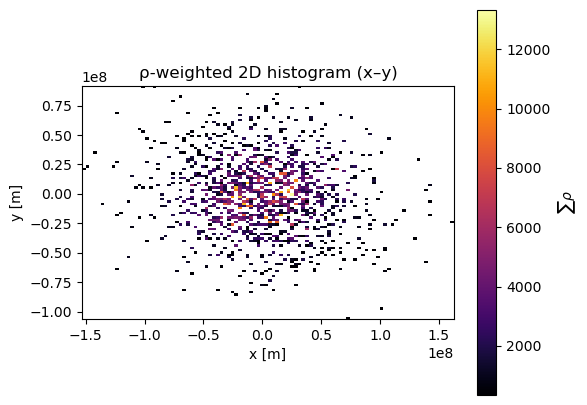

In [ ]:
nsteps=2400
dt=2

from matplotlib.animation import FuncAnimation, FFMpegWriter

x, v = recenter(x, v, m)
period = 0.41 * 24 * 3600.0       # For Jupyter, seconds
omega = np.array([0.0, 0.0, 2*np.pi/period])  # rad/s
R = np.linalg.norm(x, axis=1).max()
Mtot = m.sum()
print("R =", R/1000, "km")
print("M =", Mtot, "kg")
G = 6.67430e-11
vesc = np.sqrt(2*G*Mtot/R)
print("v_esc =", vesc, "m/s")
print("omega =", omega)
sep  = 2.8 * R
b    = 0.5 * R
#sep,b= 10e7,3e7 #separation in x, y and relative velocity

X, V, M, RHO, P, E = make_two_body_ic(x,v,m,rho,p,e,sep,b,vesc, omega)
fig, ax = plt.subplots(figsize=(5, 5))

summarize_state(x, v, m, rho, p, e, name="state")

# ---- initial frame ----
RHO = compute_density_3d(X, M, h)

hist = ax.hist2d(
    X[:, 0], X[:, 1],
    bins=90,
    weights=RHO,
    cmap="inferno",
    cmin=1e-13
)

quadmesh = hist[3]  # this is the mappable object
cbar = fig.colorbar(quadmesh, ax=ax)
cbar.set_label(r"$\sum \rho$")

ax.set_xlim(-3e8, 3e8)
ax.set_ylim(-3e8, 3e8)

def update(n):
    global X, V, E

    RHO = compute_density_3d(X, M, h)
    P   = compute_pressure(RHO, E, gamma)

    a_hydro, dEdt = compute_accel_and_dedt_3d(
        X, V, RHO, P, E, M, h,
        gamma=gamma, alphaPi=alphaPi, betaPi=betaPi
    )

    a_grav  = gravity_accel(X, M, h)
    a_total = a_hydro + a_grav

    V += dt * a_total
    E += dt * dEdt
    E = np.maximum(E, 1e-6)
    X += dt * V

    ax.clear()

    hist = ax.hist2d(
        X[:, 0], X[:, 1],
        bins=90,
        weights=RHO,
        cmap="inferno",
        cmin=1e-13
    )

    quadmesh = hist[3]

    ax.set_xlim(-3e8, 3e8)
    ax.set_ylim(-3e8, 3e8)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(f"Step {n}")

    cbar.update_normal(quadmesh)

    return (quadmesh,)

anim = FuncAnimation(fig, update, frames=nsteps, interval=30, blit=False)

writer = FFMpegWriter(fps=20)
anim.save("collapse.mp4", writer=writer, dpi=150)

plt.close(fig)

plt.figure(figsize=(6, 5))
plt.hist2d(
    X[:, 0], X[:, 1],
    bins=100,
    weights=RHO,
    cmap="inferno",
    cmin=1e-13     # anything > 0 works for weighted histograms
)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.colorbar(label=r"$\sum \rho$")
plt.title("ρ-weighted 2D histogram (x–y)")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()